In [1]:
! pip install pandas
! pip install -U scikit-learn
! pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl (8.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas # to load in our data
from sklearn import tree # to print our decision tree
from sklearn.tree import DecisionTreeClassifier # to train our decision tr

In our example, we want to decide whether or not someone is drunk at your degenerate friend's darty.

We have the following columns:

* FavoriteNumber: [INT]
* HoursAwake: [INT]
* ShotsTaken: [INT]
* Year: [STRING] 
* Drunk: [STRING]

In [3]:
# first import our dataset
df = pandas.read_csv("data copy.csv")

In [4]:
# since year is a string, we must make it an integer for the model
# to be able to learn from it. 
d = {'FIRST': 0, 'SECOND': 1, 'THIRD': 2}
df['Year'] = df['Year'].map(d)

# We do the same to our class: whether or not someone is drunk.
d = {'YES': 1, 'NO': 0}
df['Drunk'] = df['Drunk'].map(d)

d = {'GreyGoose': 0, 'Malibu': 1, 'CostcoVodka': 2, 'BuzzBall': 3, 'PinkWhitney': 4, 'Smirnoff': 5, 'Titos': 6, 'Absolut': 7, 'Everclear': 8}
df['TypeofShot'] = df['TypeofShot'].map(d)

In [5]:
# now, we define the features. The non-class columns are our features
# to determine whether or not someone is drunk
features = ['FavoriteNumber', 'TypeofShot', 'ShotsTaken', 'Year']
X = df[features]
y = df['Drunk']

# now, we train the decision tree
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

[Text(0.6, 0.8333333333333334, 'ShotsTaken <= 6.5\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.4, 0.5, 'TypeofShot <= 1.5\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.7, 0.6666666666666667, '  False')]

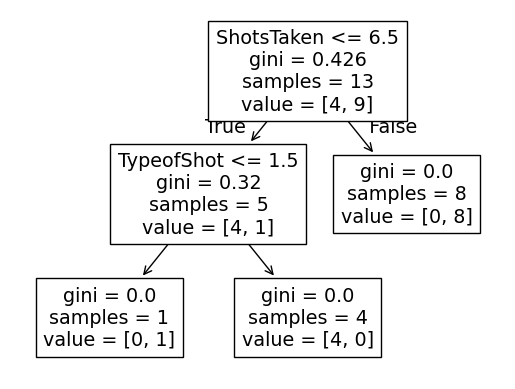

In [6]:
# let's see our tree
tree.plot_tree(dtree, feature_names=features)

To read this tree, here is the guide:
* We use the gini index to measure which features is best. Remember, a low gini index (close to 0) means a perfectly segregated split. A gini index closer to 0.5 means a perfectly even split--right down the middle.
* Our strongest feature is number of shots taken.
* To figure out whether or not someone is drunk, the boxes with gini = 0.0 on the right mean "yes" and the ones of the left mean "no"

If someone took more than 6.5 shots, they are drunk. Otherwise, we go down to the next strongest feature: ShotsTaken <= 4.5
* If someone took more than 4.5 shots, they are drunk

If someone took less than or equal to 4.5 shots, we check what they drank.
* People who drank Grey Goose or Malibu are not drunk.
* People who drank anything else (Costco Vodka, Buzzball, Pink Whitney, Smirnoff, Absolut Vodka, Everclear, Tito's) are drunk.